<a href="https://colab.research.google.com/github/DrPrime01/maizeguard/blob/main/maize_guard_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MaizeGuard — MobileNetV2 training (M1 + M2)

Trains the four-class maize leaf classifier deployed in the MaizeGuard Android app.

**Label set (fixed, PRD §8 / AT-11):** `msv`, `common_rust`, `grey_leaf_spot`, `healthy`.

The declaration order above is load-bearing. It must match, exactly:
- `lib/domain/models/disease_class.dart` (enum order)
- `assets/model/labels.txt`

Reordering any one of them without the others silently remaps every prediction —
the app will not crash, it will just be confidently wrong.

---

## Dataset sourcing, and a correction to the PRD

PRD §8 implies the whole label set comes from a filtered PlantVillage. **It cannot.**
PlantVillage's maize subset contains exactly four classes — Cercospora/Grey Leaf Spot,
Common Rust, Northern Leaf Blight, and Healthy. **There is no Maize Streak Virus in
PlantVillage.** MSV has to come from elsewhere.

| Class | Source |
|---|---|
| `common_rust` | PlantVillage — `Corn_(maize)___Common_rust_` (~1192) |
| `grey_leaf_spot` | PlantVillage — `Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot` (~513) |
| `healthy` | PlantVillage — `Corn_(maize)___healthy` (~1162) |
| `msv` | CCMT crop pest & disease dataset (Ghana), maize `streak virus` class — CC BY 4.0 |

CCMT: <https://data.mendeley.com/datasets/bwh3zbpkpv/1>  
Fallback / supplement (Tanzania, 3052 MSV images): <https://data.mendeley.com/datasets/fkw49mz3xs/1>

### The domain-shift trap

PlantVillage images are lab-style: one detached leaf, uniform grey background.
CCMT images are taken in the field. If MSV is the *only* class with field backgrounds,
the network can reach very high validation accuracy by learning **"busy background =
MSV"** and never looking at the leaf at all. That model collapses the moment a farmer
photographs a rust-infected leaf in a real field.

Two defences are built into this notebook:
1. Aggressive background-disrupting augmentation (crop, rotate, colour jitter).
2. **A held-out field-only test set** (`STRESS_TEST_DIR`) — CCMT's own maize `leaf spot`,
   `leaf blight`, and `healthy` classes. If accuracy on lab-style test data is high but
   collapses here, the model is reading backgrounds, not lesions. Report both numbers.

Section 7 measures this explicitly. Do not skip it — it is the difference between a
defensible Chapter 4 and an inflated one.

## 1. Environment

In [1]:
import os, random, shutil, pathlib, json, datetime
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU') or 'NONE — set Runtime > Change runtime type > GPU')

TensorFlow 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Fixed contract shared with the Flutter app.
CLASS_NAMES = ['msv', 'common_rust', 'grey_leaf_spot', 'healthy']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = 224          # PRD §9.1
BATCH_SIZE  = 32

DATA_ROOT       = pathlib.Path('/content/maize_data')   # <class>/<images>
SPLIT_ROOT      = pathlib.Path('/content/maize_split')  # train|val|test/<class>
STRESS_TEST_DIR = pathlib.Path('/content/maize_field_test')  # field-only, optional
EXPORT_DIR      = pathlib.Path('/content/export')
EXPORT_DIR.mkdir(exist_ok=True, parents=True)

## 2. Assemble the dataset

Download the two sources, then arrange them as `maize_data/<class_name>/*.jpg` using the
four names in `CLASS_NAMES`. The cell below only verifies and counts — do the copying in
whatever way suits where you put the files (Drive mount, Kaggle API, direct download).

**Minimum bar:** at least ~300 usable images per class. If MSV comes out far below the
others after cleaning, pull the Tanzania set in as a supplement rather than training on a
badly starved class.

### 2a. Kaggle credentials

Both datasets come from Kaggle, so the download runs on Google's network
rather than your home connection.

Kaggle now issues a single access token (`KGAT_...`) instead of a
`kaggle.json` username/key pair. Get one at
<https://www.kaggle.com/settings/api>.

**Recommended — use a Colab secret so the token never sits in the notebook:**
click the key icon in the left sidebar, add a secret named exactly
`KAGGLE_API_TOKEN`, paste the token, and enable notebook access. The cell
below picks it up automatically.

Without a secret it falls back to a hidden prompt. Either way the token is not
written to disk and will not be saved into the notebook file.

In [3]:
!pip -q install kaggle kagglehub

import os

token = os.environ.get('KAGGLE_API_TOKEN')

if not token:
    try:
        from google.colab import userdata
        token = userdata.get('KAGGLE_API_TOKEN')
        print('Token loaded from Colab secrets.')
    except Exception:
        pass

if not token:
    from getpass import getpass
    token = getpass('Paste your Kaggle access token (KGAT_...): ').strip()

# The kaggle CLI and kagglehub both read this environment variable, and `!`
# shell commands in Colab inherit it from this process.
os.environ['KAGGLE_API_TOKEN'] = token

from kagglehub.auth import whoami
print('Authenticated as:', whoami()['username'])

Token loaded from Colab secrets.
Kaggle credentials successfully validated.
Authenticated as: gabrielshoyombo


### 2b. Download the two source datasets

| Source | Supplies |
|---|---|
| PlantVillage | `common_rust`, `grey_leaf_spot`, `healthy` |
| CCMT (Ghana) | `msv` — PlantVillage has no Maize Streak Virus |

A few GB total. If a slug 404s, open the dataset page on Kaggle and use the
slug from its URL — these are community mirrors and do get renamed.

In [4]:
PLANTVILLAGE_SLUG = 'abdallahalidev/plantvillage-dataset'
CCMT_SLUG         = 'nirmalsankalana/crop-pest-and-disease-detection'

!mkdir -p /content/dl_pv /content/dl_ccmt
!kaggle datasets download -d {PLANTVILLAGE_SLUG} -p /content/dl_pv --unzip -q
!kaggle datasets download -d {CCMT_SLUG} -p /content/dl_ccmt --unzip -q
print('Downloads complete.')

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/crop-pest-and-disease-detection
License(s): CC0-1.0
Downloads complete.


### 2c. Sort the source folders into the four classes

Mirrors disagree on directory naming, so this matches on patterns rather than
fixed paths and prints exactly what it matched. **Read that output** — a wrong
match here silently poisons every number in the evaluation.

The `healthy` rule is the one to watch: PlantVillage and CCMT both contain
healthy *tomato*, *cassava* and *cashew* folders, and pulling those in would
teach the model that 'healthy' means 'not a maize leaf'.

In [5]:
# Colab clears all state when the runtime restarts, and these cells depend on
# the Section 1 constants. Fail with something actionable rather than a bare
# NameError halfway down the cell.
try:
    CLASS_NAMES, DATA_ROOT
except NameError as e:
    raise SystemExit(
        'Section 1 has not been run in this runtime.\n'
        'Fix: run the two Section 1 cells (imports, then the CLASS_NAMES\n'
        'constants). Both are instant.\n'
        'Do NOT use Runtime > Run before -- that re-runs the download in 2b.'
    ) from e
import shutil, pathlib

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
SEARCH_ROOTS = [pathlib.Path('/content/dl_pv'), pathlib.Path('/content/dl_ccmt')]

def is_maize(path_l: str) -> bool:
    return 'maize' in path_l or 'corn' in path_l

def classify_dir(p: pathlib.Path):
    """Maps a source directory to one of our four classes, or None."""
    s = str(p).lower()
    name = p.name.lower()
    # Every class must come from maize imagery.
    if not is_maize(s):
        return None
    if 'streak' in s:
        return 'msv'
    if 'rust' in s:
        return 'common_rust'
    if 'gray_leaf_spot' in s or 'grey_leaf_spot' in s or 'cercospora' in s:
        return 'grey_leaf_spot'
    # 'healthy' as the folder's own name, not merely somewhere in the path.
    if name == 'healthy' or name.endswith('___healthy'):
        return 'healthy'
    return None

# Ignore the augmented copies: they duplicate the raw images and would leak
# across the train/test split.
def is_augmented(p: pathlib.Path) -> bool:
    return 'augment' in str(p).lower()

matches = {c: [] for c in CLASS_NAMES}
for root in SEARCH_ROOTS:
    if not root.exists():
        continue
    for d in root.rglob('*'):
        if not d.is_dir() or is_augmented(d):
            continue
        cls = classify_dir(d)
        if cls is None:
            continue
        imgs = [f for f in d.iterdir() if f.suffix.lower() in IMG_EXTS]
        if imgs:
            matches[cls].append((d, len(imgs)))

print('Matched source directories:\n')
for cls in CLASS_NAMES:
    total = sum(n for _, n in matches[cls])
    print(f'{cls}  ->  {total} images')
    for d, n in matches[cls]:
        print(f'     {n:>6}  {d}')
    if total == 0:
        print('     *** NOTHING MATCHED — fix before continuing ***')
    print()

Matched source directories:

msv  ->  979 images
        979  /content/dl_ccmt/Maize streak virus

common_rust  ->  3576 images
       1192  /content/dl_pv/plantvillage dataset/grayscale/Corn_(maize)___Common_rust_
       1192  /content/dl_pv/plantvillage dataset/segmented/Corn_(maize)___Common_rust_
       1192  /content/dl_pv/plantvillage dataset/color/Corn_(maize)___Common_rust_

grey_leaf_spot  ->  1539 images
        513  /content/dl_pv/plantvillage dataset/grayscale/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
        513  /content/dl_pv/plantvillage dataset/segmented/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
        513  /content/dl_pv/plantvillage dataset/color/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot

healthy  ->  3486 images
       1162  /content/dl_pv/plantvillage dataset/grayscale/Corn_(maize)___healthy
       1162  /content/dl_pv/plantvillage dataset/segmented/Corn_(maize)___healthy
       1162  /content/dl_pv/plantvillage dataset/color/Corn_(maize

In [6]:
# Colab clears all state when the runtime restarts, and these cells depend on
# the Section 1 constants. Fail with something actionable rather than a bare
# NameError halfway down the cell.
try:
    CLASS_NAMES, DATA_ROOT
except NameError as e:
    raise SystemExit(
        'Section 1 has not been run in this runtime.\n'
        'Fix: run the two Section 1 cells (imports, then the CLASS_NAMES\n'
        'constants). Both are instant.\n'
        'Do NOT use Runtime > Run before -- that re-runs the download in 2b.'
    ) from e
# Copy into the flat DATA_ROOT/<class>/ layout the rest of the notebook expects.
if DATA_ROOT.exists():
    shutil.rmtree(DATA_ROOT)

for cls in CLASS_NAMES:
    out = DATA_ROOT / cls
    out.mkdir(parents=True, exist_ok=True)
    n = 0
    for d, _ in matches[cls]:
        for f in d.iterdir():
            if f.suffix.lower() in IMG_EXTS:
                # Prefix with the source folder so same-named files cannot collide.
                shutil.copy2(f, out / f'{d.name}__{f.name}')
                n += 1
    print(f'{cls:<16} {n:>6} images')

print('\nNow run the audit cell below.')

msv                 979 images
common_rust        3576 images
grey_leaf_spot     1539 images
healthy            3486 images

Now run the audit cell below.


In [9]:
def audit(root: pathlib.Path):
    """Counts images per class and fails loudly on anything unusable."""
    if not root.exists():
        raise SystemExit(f'{root} does not exist — assemble the dataset first.')
    exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    counts = {}
    for name in CLASS_NAMES:
        d = root / name
        if not d.exists():
            raise SystemExit(f'Missing class directory: {d}')
        counts[name] = sum(1 for f in d.iterdir() if f.suffix.lower() in exts)
    total = sum(counts.values())
    print(f'{total} images across {len(counts)} classes\n')
    for name, n in counts.items():
        print(f'  {name:<16} {n:>6}  ({n / total:.1%})')
    smallest, largest = min(counts.values()), max(counts.values())
    ratio = largest / max(smallest, 1)
    print(f'\nImbalance ratio {ratio:.1f}:1')
    if ratio > 3:
        print('  WARNING: heavy imbalance. Class weights (section 5) help, but consider',
              'collecting more of the minority class.')
    if smallest < 300:
        print(f'  WARNING: smallest class has only {smallest} images.')
    return counts

counts = audit(DATA_ROOT)

6713 images across 4 classes

  msv                 979  (14.6%)
  common_rust        2384  (35.5%)
  grey_leaf_spot     1026  (15.3%)
  healthy            2324  (34.6%)

Imbalance ratio 2.4:1


In [8]:
# Deduplicate by content hash.
# Public plant-disease sets are notorious for repeats, and a duplicate that lands in
# both train and test leaks the answer and inflates the reported accuracy.
import hashlib

def drop_duplicates(root: pathlib.Path):
    seen, removed = {}, 0
    for cls in CLASS_NAMES:
        for f in sorted((root / cls).iterdir()):
            if not f.is_file():
                continue
            h = hashlib.md5(f.read_bytes()).hexdigest()
            if h in seen:
                f.unlink(); removed += 1
            else:
                seen[h] = f
    print(f'Removed {removed} exact duplicates.')

drop_duplicates(DATA_ROOT)
counts = audit(DATA_ROOT)

Removed 0 exact duplicates.
6713 images across 4 classes

  msv                 979  (14.6%)
  common_rust        2384  (35.5%)
  grey_leaf_spot     1026  (15.3%)
  healthy            2324  (34.6%)

Imbalance ratio 2.4:1


### 2e. Remove undecodable images

Public plant-disease datasets routinely contain a handful of truncated or
malformed JPEGs. They pass a file-extension check and then blow up inside
`model.fit` with `jpeg::Uncompress failed`, often minutes into an epoch.

This decodes every file with the **same TensorFlow decoder the training
pipeline uses**, so anything that survives here cannot fail during training.
A PIL check is not sufficient — the two decoders disagree on edge cases.

Run this once. Then re-run sections 3-6 (split, pipeline, class weights,
model) so the splits are rebuilt from the cleaned files.

In [10]:
try:
    CLASS_NAMES, DATA_ROOT
except NameError as e:
    raise SystemExit('Run the two Section 1 cells first.') from e

import tensorflow as tf

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def decodable(path) -> bool:
    try:
        data = tf.io.read_file(str(path))
        img = tf.io.decode_image(data, channels=3, expand_animations=False)
        # A valid file can still be degenerate (zero width/height).
        return bool(img.shape[0]) and bool(img.shape[1])
    except Exception:
        return False

removed, kept = 0, 0
for cls in CLASS_NAMES:
    d = DATA_ROOT / cls
    bad = []
    for f in sorted(d.iterdir()):
        if not f.is_file():
            continue
        # image_dataset_from_directory only reads these extensions; anything
        # else is dead weight that would never be loaded anyway.
        if f.suffix.lower() not in IMG_EXTS or not decodable(f):
            bad.append(f)
        else:
            kept += 1
    for f in bad:
        f.unlink()
    removed += len(bad)
    print(f'{cls:<16} removed {len(bad):>4}')

print(f'\nRemoved {removed} unusable files, {kept} good images remain.')
print('Now re-run sections 3, 4, 5 and 6 before training again.')

msv              removed   14
common_rust      removed    0
grey_leaf_spot   removed    0
healthy          removed    0

Removed 14 unusable files, 6699 good images remain.
Now re-run sections 3, 4, 5 and 6 before training again.


## 3. Stratified train / validation / test split

70 / 15 / 15, stratified per class, split on **files** before any augmentation so no
augmented variant of a training image can appear in the test set.

In [11]:
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15

def make_splits(src: pathlib.Path, dst: pathlib.Path):
    if dst.exists():
        shutil.rmtree(dst)
    summary = {}
    for cls in CLASS_NAMES:
        files = sorted(f for f in (src / cls).iterdir() if f.is_file())
        random.Random(SEED).shuffle(files)
        n = len(files)
        n_train, n_val = int(n * TRAIN_FRAC), int(n * VAL_FRAC)
        parts = {
            'train': files[:n_train],
            'val':   files[n_train:n_train + n_val],
            'test':  files[n_train + n_val:],
        }
        for split, items in parts.items():
            out = dst / split / cls
            out.mkdir(parents=True, exist_ok=True)
            for f in items:
                shutil.copy2(f, out / f.name)
        summary[cls] = {k: len(v) for k, v in parts.items()}
    return summary

split_summary = make_splits(DATA_ROOT, SPLIT_ROOT)
for cls, s in split_summary.items():
    print(f"{cls:<16} train={s['train']:>5}  val={s['val']:>5}  test={s['test']:>5}")

msv              train=  675  val=  144  test=  146
common_rust      train= 1668  val=  357  test=  359
grey_leaf_spot   train=  718  val=  153  test=  155
healthy          train= 1626  val=  348  test=  350


## 4. Input pipeline

### Preprocessing contract — read this before changing anything

Inputs are scaled to **[-1, 1]** (`mobilenet_v2.preprocess_input`), and that scaling is
applied **in the data pipeline, not inside the model**. The exported TFLite therefore
expects an already-scaled tensor, which is exactly what
`Preprocess.toModelInput()` in `lib/ml/preprocess.dart` produces:

```dart
buffer[i++] = (pixel.r / 127.5) - 1.0;
```

If you move the rescaling *into* the model, the app will double-scale every image and
accuracy will quietly fall apart with no error anywhere. Change both sides or neither.

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

def load_split(split: str, shuffle: bool):
    return tf.keras.utils.image_dataset_from_directory(
        SPLIT_ROOT / split,
        labels='inferred',
        label_mode='categorical',
        class_names=CLASS_NAMES,   # pins label order to the app's enum
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )

raw_train = load_split('train', shuffle=True)
raw_val   = load_split('val',   shuffle=False)
raw_test  = load_split('test',  shuffle=False)
assert raw_train.class_names == CLASS_NAMES, raw_train.class_names

Found 4687 files belonging to 4 classes.
Found 1002 files belonging to 4 classes.
Found 1010 files belonging to 4 classes.


In [13]:
# Augmentation is tuned to break the lab-vs-field background shortcut described up top.
# Random crop + rotation + colour jitter make background statistics an unreliable cue,
# which pushes the network towards lesion texture and shape.
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.25),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2, value_range=(0.0, 255.0)),
], name='augment')

preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = (raw_train
            .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
val_ds   = raw_val.map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = raw_test.map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

## 5. Class weights

Grey Leaf Spot is roughly half the size of Common Rust in PlantVillage (PRD §21 flags
this). Without weighting, the model can score well overall while being poor at exactly
the class a farmer most needs identified.

In [14]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = []
for cls_idx, cls in enumerate(CLASS_NAMES):
    train_labels += [cls_idx] * split_summary[cls]['train']
train_labels = np.array(train_labels)

weights = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_labels)
class_weight = {i: float(w) for i, w in enumerate(weights)}
for i, name in enumerate(CLASS_NAMES):
    print(f'{name:<16} weight {class_weight[i]:.3f}')

msv              weight 1.736
common_rust      weight 0.702
grey_leaf_spot   weight 1.632
healthy          weight 0.721


## 6. Model — MobileNetV2 transfer learning

PRD §20 resolves the MobileNetV2 vs V3 inconsistency in the chapters in favour of **V2**.

Two stages: train the head with the base frozen, then unfreeze the top of the base and
fine-tune at a much lower learning rate. Fine-tuning at the full rate would wreck the
pretrained features before the randomly-initialised head has stabilised.

In [15]:
def build_model():
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    # Softmax in the graph: the app reads probabilities straight out of the
    # interpreter and shows them as a confidence score.
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs), base

model, base = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                     restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3),
]

history_head = model.fit(train_ds, validation_data=val_ds, epochs=20,
                         class_weight=class_weight, callbacks=callbacks)

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 117s 648ms/step - accuracy: 0.8511 - loss: 0.4227 - val_accuracy: 0.9701 - val_loss: 0.1097 - learning_rate: 0.0010
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 100s 477ms/step - accuracy: 0.9603 - loss: 0.1371 - val_accuracy: 0.9870 - val_loss: 0.0539 - learning_rate: 0.0010
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 81s 470ms/step - accuracy: 0.9718 - loss: 0.1006 - val_accuracy: 0.9920 - val_loss: 0.0425 - learning_rate: 0.0010
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 73s 490ms/step - accuracy: 0.9682 - loss: 0.1030 - val_accuracy: 0.9880 - val_loss: 0.0515 - learning_rate: 0.0010
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 88s 593ms/step - accuracy: 0.9725 - loss: 0.0836 - val_accuracy: 0.9920 - val_loss: 0.0339 - learning_rate: 0.0010
Epoch 6/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 70s 473ms/step - accuracy: 0.9742 - loss: 0.0819 - val_accuracy: 0.9900 - val_loss: 0.0326 - learning_rate: 0.0010
Epoch 7/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 82s 472ms/step - accuracy: 0

In [17]:
# Fine-tune the top third of the base at a low learning rate.
base.trainable = True
FREEZE_UNTIL = len(base.layers) * 2 // 3
for layer in base.layers[:FREEZE_UNTIL]:
    layer.trainable = False
# BatchNorm stays frozen: updating its statistics on small batches is a classic
# way to destroy a fine-tune.
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
history_ft = model.fit(train_ds, validation_data=val_ds, epochs=15,
                       class_weight=class_weight, callbacks=callbacks)

Epoch 1/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 103s 579ms/step - accuracy: 0.9733 - loss: 0.0861 - val_accuracy: 0.9890 - val_loss: 0.0279 - learning_rate: 1.0000e-05
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 71s 479ms/step - accuracy: 0.9763 - loss: 0.0670 - val_accuracy: 0.9930 - val_loss: 0.0209 - learning_rate: 1.0000e-05
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 72s 484ms/step - accuracy: 0.9827 - loss: 0.0535 - val_accuracy: 0.9950 - val_loss: 0.0194 - learning_rate: 1.0000e-05
Epoch 4/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 71s 480ms/step - accuracy: 0.9861 - loss: 0.0436 - val_accuracy: 0.9950 - val_loss: 0.0165 - learning_rate: 1.0000e-05
Epoch 5/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 99s 599ms/step - accuracy: 0.9851 - loss: 0.0406 - val_accuracy: 0.9950 - val_loss: 0.0129 - learning_rate: 1.0000e-05
Epoch 6/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 71s 482ms/step - accuracy: 0.9889 - loss: 0.0377 - val_accuracy: 0.9950 - val_loss: 0.0135 - learning_rate: 1.0000e-05
Epoch 7/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 83s 4

## 7. Evaluation (PRD §9.3, Objective 4)

Accuracy, precision, recall, F1, and the 4×4 confusion matrix — plus the field-only
stress test that checks the model is reading lesions rather than backgrounds.

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_fscore_support)

y_prob = model.predict(test_ds)
y_pred = y_prob.argmax(axis=1)
y_true = np.concatenate([y.numpy().argmax(axis=1) for _, y in test_ds])

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

p, r, f1, sup = precision_recall_fscore_support(y_true, y_pred, average='macro')
acc = (y_true == y_pred).mean()
print(f'Accuracy {acc:.4f} | macro P {p:.4f} | macro R {r:.4f} | macro F1 {f1:.4f}')

32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 428ms/step
                precision    recall  f1-score   support

           msv     1.0000    0.9863    0.9931       146
   common_rust     0.9972    0.9916    0.9944       359
grey_leaf_spot     0.9686    0.9935    0.9809       155
       healthy     1.0000    1.0000    1.0000       350

      accuracy                         0.9941      1010
     macro avg     0.9914    0.9929    0.9921      1010
  weighted avg     0.9942    0.9941    0.9941      1010

Accuracy 0.9941 | macro P 0.9914 | macro R 0.9929 | macro F1 0.9921


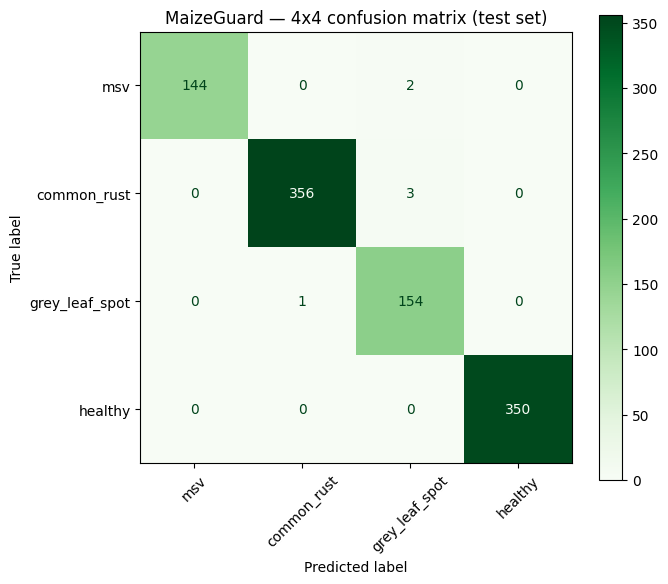

msv              recall 0.986   (144/146)
common_rust      recall 0.992   (356/359)
grey_leaf_spot   recall 0.994   (154/155)
healthy          recall 1.000   (350/350)


In [19]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap='Greens',
                                                            xticks_rotation=45)
ax.set_title('MaizeGuard — 4x4 confusion matrix (test set)')
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'confusion_matrix.png', dpi=200)
plt.show()

# Per-class recall is the number that matters in the field: it answers
# 'when this disease is present, how often do we catch it?'
for i, name in enumerate(CLASS_NAMES):
    recall = cm[i, i] / max(cm[i].sum(), 1)
    print(f'{name:<16} recall {recall:.3f}   ({cm[i, i]}/{cm[i].sum()})')

In [20]:
# Threshold sweep — evidence for choosing the app's confidence threshold.
# PRD §9.2 quotes 95% as an example and §20 says the real value must be justified
# from validation results. This table is that justification.
confidence = y_prob.max(axis=1)
correct = (y_pred == y_true)
print(f'{"thresh":>7} {"kept":>7} {"coverage":>9} {"precision":>10}')
for t in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]:
    keep = confidence >= t
    coverage = keep.mean()
    precision = correct[keep].mean() if keep.any() else float('nan')
    print(f'{t:>7.2f} {keep.sum():>7} {coverage:>9.1%} {precision:>10.1%}')
print('\nPick the lowest threshold whose precision is acceptable: a high threshold that',
      'rejects most scans is useless to a farmer standing in a field.')

 thresh    kept  coverage  precision
   0.50    1010    100.0%      99.4%
   0.60    1006     99.6%      99.6%
   0.70    1002     99.2%      99.9%
   0.80     995     98.5%     100.0%
   0.90     986     97.6%     100.0%
   0.95     976     96.6%     100.0%
   0.99     938     92.9%     100.0%

Pick the lowest threshold whose precision is acceptable: a high threshold that rejects most scans is useless to a farmer standing in a field.


In [21]:
# Field-only stress test (optional but strongly recommended).
# Only meaningful if STRESS_TEST_DIR holds in-field images the model never saw.
if STRESS_TEST_DIR.exists():
    stress_raw = tf.keras.utils.image_dataset_from_directory(
        STRESS_TEST_DIR, labels='inferred', label_mode='categorical',
        class_names=CLASS_NAMES, image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, shuffle=False)
    stress = stress_raw.map(lambda x, y: (preprocess(x), y))
    s_prob = model.predict(stress)
    s_true = np.concatenate([y.numpy().argmax(axis=1) for _, y in stress])
    s_acc = (s_prob.argmax(axis=1) == s_true).mean()
    print(f'Lab-style test accuracy : {acc:.3f}')
    print(f'Field-only accuracy     : {s_acc:.3f}')
    if acc - s_acc > 0.15:
        print('\nLarge gap. The model is leaning on background cues rather than lesions.',
              '\nReport both numbers in Chapter 4 and treat the lab figure as optimistic.')
else:
    print('No field stress set present — skipping.',
          '\nStrongly consider building one: it is the difference between a defensible',
          'accuracy claim and an inflated one.')

No field stress set present — skipping. 
Strongly consider building one: it is the difference between a defensible accuracy claim and an inflated one.


## 8. Export to TensorFlow Lite

Float16 is the deployment default: roughly half the size of float32 with negligible
accuracy loss and no need for a representative dataset. Int8 is also produced for
comparison — quote both sizes and both latencies in the evaluation.

In [22]:
model.save(EXPORT_DIR / 'maize_mobilenetv2.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_fp16 = converter.convert()
fp16_path = EXPORT_DIR / 'maize_mobilenetv2.tflite'
fp16_path.write_bytes(tflite_fp16)
print(f'float16: {len(tflite_fp16) / 1e6:.2f} MB -> {fp16_path.name}')

Saved artifact at '/tmp/tmp4hhbtpub'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_161')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133692536215056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536221392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536222544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536223120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536220816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536222736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536223888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536223696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536224080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536222352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1336925362

In [23]:
# Int8 needs real samples to calibrate activation ranges.
def representative_dataset():
    for images, _ in val_ds.take(50):
        for i in range(images.shape[0]):
            yield [tf.expand_dims(images[i], 0)]

int8_converter = tf.lite.TFLiteConverter.from_keras_model(model)
int8_converter.optimizations = [tf.lite.Optimize.DEFAULT]
int8_converter.representative_dataset = representative_dataset
tflite_int8 = int8_converter.convert()
int8_path = EXPORT_DIR / 'maize_mobilenetv2_int8.tflite'
int8_path.write_bytes(tflite_int8)
print(f'int8: {len(tflite_int8) / 1e6:.2f} MB -> {int8_path.name}')

Saved artifact at '/tmp/tmpckctzand'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_161')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133692536215056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536221392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536222544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536223120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536220816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536222736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536223888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536223696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536224080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133692536222352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1336925362

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


int8: 2.72 MB -> maize_mobilenetv2_int8.tflite


## 9. Verify the export before shipping it

Three things the app depends on, checked here rather than discovered on a phone.

In [24]:
interpreter = tf.lite.Interpreter(model_content=tflite_fp16)
interpreter.allocate_tensors()
inp, out = interpreter.get_input_details()[0], interpreter.get_output_details()[0]
print('input ', inp['shape'], inp['dtype'])
print('output', out['shape'], out['dtype'])

# 1. AT-11: exactly four outputs. TfliteClassifier.load() refuses anything else.
assert out['shape'][-1] == NUM_CLASSES, f"expected {NUM_CLASSES} outputs, got {out['shape'][-1]}"
assert tuple(inp['shape'][1:3]) == (IMG_SIZE, IMG_SIZE), 'input size must be 224x224'

# 2. TFLite must agree with Keras. A big gap means the conversion degraded the model.
batch = next(iter(test_ds))[0][:16]
keras_pred = model.predict(batch, verbose=0).argmax(axis=1)
tflite_pred = []
for i in range(batch.shape[0]):
    interpreter.set_tensor(inp['index'], tf.expand_dims(batch[i], 0).numpy())
    interpreter.invoke()
    tflite_pred.append(interpreter.get_tensor(out['index'])[0].argmax())
agreement = (keras_pred == np.array(tflite_pred)).mean()
print(f'Keras/TFLite agreement on 16 samples: {agreement:.1%}')
assert agreement >= 0.9, 'conversion changed predictions — investigate before shipping'

# 3. Probabilities, not logits — the app shows this number as a confidence score.
interpreter.set_tensor(inp['index'], tf.expand_dims(batch[0], 0).numpy())
interpreter.invoke()
probs = interpreter.get_tensor(out['index'])[0]
print('output sums to', float(probs.sum()), '(should be ~1.0)')

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


input  [  1 224 224   3] <class 'numpy.float32'>
output [1 4] <class 'numpy.float32'>
Keras/TFLite agreement on 16 samples: 100.0%
output sums to 1.0 (should be ~1.0)


In [25]:
# labels.txt, in the one true order.
(EXPORT_DIR / 'labels.txt').write_text('\n'.join(CLASS_NAMES) + '\n')

metrics = {
    'trained_at': datetime.datetime.now().isoformat(timespec='seconds'),
    'class_names': CLASS_NAMES,
    'test_accuracy': float(acc),
    'macro_precision': float(p),
    'macro_recall': float(r),
    'macro_f1': float(f1),
    'confusion_matrix': cm.tolist(),
    'split_summary': split_summary,
    'tflite_fp16_bytes': len(tflite_fp16),
    'tflite_int8_bytes': len(tflite_int8),
}
(EXPORT_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2)[:600])

{
  "trained_at": "2026-09-01T23:57:48",
  "class_names": [
    "msv",
    "common_rust",
    "grey_leaf_spot",
    "healthy"
  ],
  "test_accuracy": 0.994059405940594,
  "macro_precision": 0.9914380846678295,
  "macro_recall": 0.9928733027496963,
  "macro_f1": 0.9921021439605785,
  "confusion_matrix": [
    [
      144,
      0,
      2,
      0
    ],
    [
      0,
      356,
      3,
      0
    ],
    [
      0,
      1,
      154,
      0
    ],
    [
      0,
      0,
      0,
      350
    ]
  ],
  "split_summary": {
    "msv": {
      "train": 675,
      "val": 144,
      "test": 146



## 10. Install into the app

```bash
# from the repo root
cp export/maize_mobilenetv2.tflite assets/model/maize_mobilenetv2.tflite
cp export/labels.txt               assets/model/labels.txt
```

Then switch the app off the stub — in `lib/app/providers.dart`:

```dart
const bool kUseTrainedModel = true;   // was false
```

Rebuild and run. `TfliteClassifier.load()` validates the output shape on startup, so a
mismatched model fails immediately and loudly rather than mislabelling scans.

Keep `metrics.json` and `confusion_matrix.png` — they are the Chapter 4 evidence.